# Wav2Vec2 on CVT (classification pipeline)

Ноутбук делает две вещи:
1. Быстрый EDA по CVT (только основные распределения).
2. Fine-tuning `facebook/wav2vec2-base` для классификации `nominal_mode` (`neutral`, `curbing`, `overdrive`, `edge`).

## Что на выходе
- метрики на validation: `accuracy`, `f1_macro`, `precision_macro`, `recall_macro`
- `classification_report`
- `confusion_matrix`
- сохраненный чекпоинт и таблицы с метриками


In [13]:
# !pip install -U "transformers[torch]" datasets accelerate evaluate librosa soundfile torchaudio scikit-learn seaborn

import inspect
import json
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torchaudio
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split

from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

print('torch:', torch.__version__)


torch: 2.10.0+cu128


In [ ]:
# Config
SEED = 42
VAL_SIZE = 0.1

MODEL_CHECKPOINT = 'facebook/wav2vec2-base'
NUM_EPOCHS = 20
LEARNING_RATE = 3e-4
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 4
MAX_AUDIO_SEC = 3.0
FREEZE_FEATURE_ENCODER = True
EARLY_STOPPING_PATIENCE = 2

INCLUDE_EXCLUDED = False  # ExcludedSamples из CVT
MIN_DURATION_SEC = 0.2
TRAIN_SOURCE = 'messmikrofon'  # только этот источник идет в обучение

MAX_TRAIN_SAMPLES = None  # например: 3000 для быстрого прогона
MAX_VAL_SAMPLES = None


FORCE_CPU = False


def cuda_backend_ok() -> bool:
    if FORCE_CPU:
        return False
    if not torch.cuda.is_available():
        return False
    try:
        x = torch.tensor([0.0], device='cuda')
        y = x + 1.0
        _ = float(y.item())
        torch.cuda.synchronize()
        return True
    except Exception as e:
        print(f'CUDA disabled due to runtime incompatibility: {e}')
        return False


USE_CUDA = cuda_backend_ok()
DEVICE = 'cuda' if USE_CUDA else 'cpu'
print('Training device:', DEVICE)

RUN_NAME = 'wav2vec2_cvt_full_tuning'
OUTPUT_ROOT = Path('outputs/wav2vec2_cvt')


def slugify_run_name(name: str) -> str:
    s = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(name))
    while '__' in s:
        s = s.replace('__', '_')
    s = s.strip('_')
    return s or 'run'


def get_output_dir_for_run(run_name: str) -> Path:
    run_dir = OUTPUT_ROOT / slugify_run_name(run_name)
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir


OUTPUT_DIR = get_output_dir_for_run(RUN_NAME)
print('RUN_NAME =', RUN_NAME)
print('OUTPUT_DIR =', OUTPUT_DIR)


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


In [15]:
# Locate dataset and read CSV
CVT_CSV_REL = Path('data/eda_cache/cvt_audio_v3.csv')


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / CVT_CSV_REL).exists():
            return p
    raise FileNotFoundError(f'Could not find {CVT_CSV_REL} in current dir or parents')


PROJECT_ROOT = find_project_root()
CVT_CSV = PROJECT_ROOT / CVT_CSV_REL

print('PROJECT_ROOT =', PROJECT_ROOT)
print('CVT_CSV =', CVT_CSV)

raw_df = pd.read_csv(CVT_CSV)
print('raw shape:', raw_df.shape)
raw_df.head()


PROJECT_ROOT = /home/evgeniy/Projects/VocalAssistant
CVT_CSV = /home/evgeniy/Projects/VocalAssistant/data/eda_cache/cvt_audio_v3.csv
raw shape: (13438, 20)


,dataset,is_excluded,folder_device,folder_mode,speaker_id,speaker_gender,nominal_mode,vowel,note,source_in_name,repetition,sample_rate,n_channels,n_frames,duration_sec,bit_depth,read_error,path,file_name,stem
0,CVT,True,NaN,NaN,s1,female,edge,ö,4C,MotorolaOne,2,44100,1,70560,1.600000,16,NaN,datasets/CVT/ExcludedSamples/s1_edge_ö_4C_Moto...,s1_edge_ö_4C_MotorolaOne_02.wav,s1_edge_ö_4C_MotorolaOne_02
1,CVT,True,NaN,NaN,s1,female,curbing,oe,4B,MotorolaOne,2,44100,1,35876,0.813515,16,NaN,datasets/CVT/ExcludedSamples/s1_curbing_oe_4B_...,s1_curbing_oe_4B_MotorolaOne_02.wav,s1_curbing_oe_4B_MotorolaOne_02
2,CVT,True,NaN,NaN,s2,male,neutral,i,1F,Messmikrofon,0,44100,1,84672,1.920000,16,NaN,datasets/CVT/ExcludedSamples/s2_neutral_i_1F_M...,s2_neutral_i_1F_Messmikrofon_00.wav,s2_neutral_i_1F_Messmikrofon_00
3,CVT,True,NaN,NaN,s2,male,neutral,ee,3F,behringer,3,44100,1,44541,1.010000,16,NaN,datasets/CVT/ExcludedSamples/s2_neutral_ee_3F_...,s2_neutral_ee_3F_behringer_03.wav,s2_neutral_ee_3F_behringer_03
4,CVT,True,NaN,NaN,s2,male,edge,ö,2A,behringer,4,44100,1,40131,0.910000,16,NaN,datasets/CVT/ExcludedSamples/s2_edge_ö_2A_behr...,s2_edge_ö_2A_behringer_04.wav,s2_edge_ö_2A_behringer_04


In [16]:
# Prepare CVT dataframe for classification
TARGET_COL = 'nominal_mode'
VALID_LABELS = ['neutral', 'curbing', 'overdrive', 'edge']


def to_abs_path(p: str | Path) -> str:
    p = Path(p)
    if p.is_absolute():
        return str(p)
    return str((PROJECT_ROOT / p).resolve())


def normalize_bool_series(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .isin({'1', 'true', 'yes'})
    )


def normalize_source_series(s: pd.Series) -> pd.Series:
    # Unify variants like "Messmikrofon", "mess_mikrofon", etc.
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r'[^a-z0-9]+', '', regex=True)
    )


def normalize_source_name(name: str) -> str:
    return ''.join(ch for ch in str(name).lower() if ch.isalnum())


df = raw_df.copy()

if not INCLUDE_EXCLUDED and 'is_excluded' in df.columns:
    excluded_mask = normalize_bool_series(df['is_excluded'])
    df = df[~excluded_mask].copy()

# Keep only target labels
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip().str.lower()
df = df[df[TARGET_COL].isin(VALID_LABELS)].copy()

# Keep only selected source (messmikrofon)
if 'source_in_name' not in df.columns:
    raise ValueError('Expected column source_in_name in CVT metadata, but it was not found.')

target_source_norm = normalize_source_name(TRAIN_SOURCE)
df['source_norm'] = normalize_source_series(df['source_in_name'])
before_source_filter = len(df)
df = df[df['source_norm'] == target_source_norm].copy()
print(f'Source filter: kept {len(df)} of {before_source_filter} rows for source={TRAIN_SOURCE}')

if 'duration_sec' in df.columns:
    df = df[df['duration_sec'].fillna(0) >= MIN_DURATION_SEC].copy()

# Build absolute paths and filter missing files
df['path'] = df['path'].astype(str).map(to_abs_path)
exists_mask = df['path'].map(lambda p: Path(p).exists())
missing = int((~exists_mask).sum())
if missing > 0:
    print('missing audio files:', missing)
df = df[exists_mask].reset_index(drop=True)

# Minimal training columns
df['group_id'] = df['speaker_id'].astype(str)
df['label'] = df[TARGET_COL]

print('prepared shape:', df.shape)
print(df['label'].value_counts().to_string())


Source filter: kept 3752 of 13335 rows for source=messmikrofon
prepared shape: (3752, 23)
label
neutral      1605
edge          841
overdrive     664
curbing       642


In [17]:
df.head()


,dataset,is_excluded,folder_device,folder_mode,speaker_id,speaker_gender,nominal_mode,vowel,note,source_in_name,...,n_frames,duration_sec,bit_depth,read_error,path,file_name,stem,source_norm,group_id,label
0,CVT,False,Messmikrofon,Neutral,s3,male,neutral,a,2F,Messmikrofon,...,43340,0.982766,16,NaN,/home/evgeniy/Projects/VocalAssistant/datasets...,s3_neutral_a_2F_Messmikrofon_01.wav,s3_neutral_a_2F_Messmikrofon_01,messmikrofon,s3,neutral
1,CVT,False,Messmikrofon,Neutral,s1,female,neutral,a,4D#,Messmikrofon,...,79380,1.800000,16,NaN,/home/evgeniy/Projects/VocalAssistant/datasets...,s1_neutral_a_4D#_Messmikrofon_12.wav,s1_neutral_a_4D#_Messmikrofon_12,messmikrofon,s1,neutral
2,CVT,False,Messmikrofon,Neutral,s2,male,neutral,oe,3F#,Messmikrofon,...,88907,2.016032,16,NaN,/home/evgeniy/Projects/VocalAssistant/datasets...,s2_neutral_oe_3F#_Messmikrofon_07.wav,s2_neutral_oe_3F#_Messmikrofon_07,messmikrofon,s2,neutral
3,CVT,False,Messmikrofon,Neutral,s4,female,neutral,ö,4C#,Messmikrofon,...,72906,1.653197,16,NaN,/home/evgeniy/Projects/VocalAssistant/datasets...,s4_neutral_ö_4C#_Messmikrofon_11.wav,s4_neutral_ö_4C#_Messmikrofon_11,messmikrofon,s4,neutral
4,CVT,False,Messmikrofon,Neutral,s1,female,neutral,ae,4F,Messmikrofon,...,85554,1.940000,16,NaN,/home/evgeniy/Projects/VocalAssistant/datasets...,s1_neutral_ae_4F_Messmikrofon_08.wav,s1_neutral_ae_4F_Messmikrofon_08,messmikrofon,s1,neutral


/tmp/ipykernel_48315/880880269.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cls_counts.index, y=cls_counts.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_48315/880880269.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[1], palette='mako')


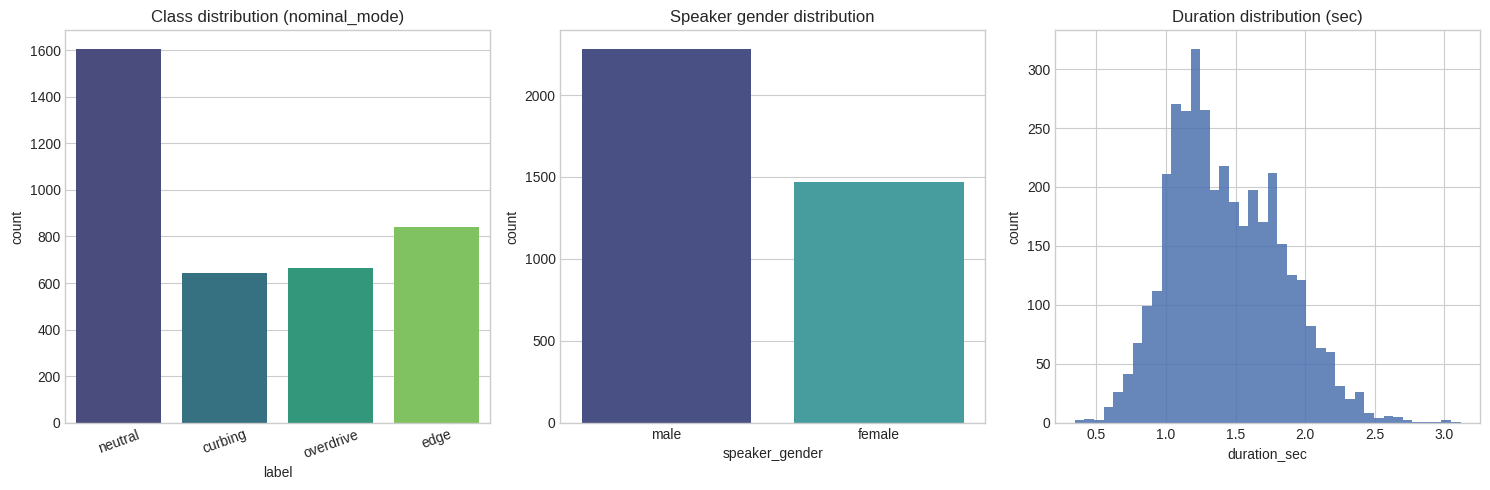

Class x Speaker gender crosstab:
label           curbing  edge  neutral  overdrive
speaker_gender                                   
female              278   298      660        235
male                364   543      945        429


In [23]:
# Basic EDA: key distributions
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # figsize скорректирован под горизонтальное расположение

# 1) class distribution
cls_counts = df['label'].value_counts().reindex(VALID_LABELS, fill_value=0)
sns.barplot(x=cls_counts.index, y=cls_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Class distribution (nominal_mode)')
axes[0].set_xlabel('label')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=20)

# 2) speaker_gender distribution (if present)
if 'speaker_gender' in df.columns:
    gender_counts = df['speaker_gender'].fillna('unknown').astype(str).str.lower().value_counts()
    sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[1], palette='mako')
    axes[1].set_title('Speaker gender distribution')
    axes[1].set_xlabel('speaker_gender')
    axes[1].set_ylabel('count')
else:
    axes[1].text(0.5, 0.5, 'speaker_gender not available', ha='center', va='center')
    axes[1].set_axis_off()

# 3) duration distribution
if 'duration_sec' in df.columns:
    axes[2].hist(df['duration_sec'].dropna(), bins=40, color='#4C72B0', alpha=0.85)
    axes[2].set_title('Duration distribution (sec)')
    axes[2].set_xlabel('duration_sec')
    axes[2].set_ylabel('count')
else:
    axes[2].text(0.5, 0.5, 'duration_sec not available', ha='center', va='center')
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

# Исправление: вероятно, вы хотели посмотреть crosstab между speaker_gender и label,
# а не между group_id и label (group_id обычно не имеет смысла для такого анализа)
if 'speaker_gender' in df.columns:
    print('Class x Speaker gender crosstab:')
    print(pd.crosstab(df['speaker_gender'].fillna('unknown'), df['label']))
else:
    print("Column 'speaker_gender' not available for crosstab.")


In [24]:
# Split train/validation (group-aware by speaker_id)
def maybe_subsample(df_in: pd.DataFrame, max_n: int | None, seed: int = 42) -> pd.DataFrame:
    if max_n is None or len(df_in) <= max_n:
        return df_in.reset_index(drop=True)
    return df_in.sample(n=max_n, random_state=seed).reset_index(drop=True)


labels_all = set(df['label'].unique())
splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(splitter.split(df, y=df['label'], groups=df['group_id']))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

# Fallback in case grouped split dropped any label
if set(train_df['label'].unique()) != labels_all or set(val_df['label'].unique()) != labels_all:
    print('Grouped split missed at least one label -> fallback to stratified split.')
    train_df, val_df = train_test_split(
        df,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=df['label'],
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

train_df = maybe_subsample(train_df, MAX_TRAIN_SAMPLES, seed=SEED)
val_df = maybe_subsample(val_df, MAX_VAL_SAMPLES, seed=SEED)

labels_sorted = sorted(train_df['label'].unique())
label2id = {lbl: i for i, lbl in enumerate(labels_sorted)}
id2label = {i: lbl for lbl, i in label2id.items()}

train_df['label_id'] = train_df['label'].map(label2id).astype(int)
val_df['label_id'] = val_df['label'].map(label2id).astype(int)

print('train size:', len(train_df), '| val size:', len(val_df))
print('train labels:', train_df['label'].value_counts().to_dict())
print('val labels:', val_df['label'].value_counts().to_dict())
print('label2id:', label2id)


train size: 2713 | val size: 1039
train labels: {'neutral': 1169, 'edge': 579, 'curbing': 489, 'overdrive': 476}
val labels: {'neutral': 436, 'edge': 262, 'overdrive': 188, 'curbing': 153}
label2id: {'curbing': 0, 'edge': 1, 'neutral': 2, 'overdrive': 3}


In [25]:
# Build HF datasets + collator + metrics
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_CHECKPOINT)
sampling_rate = int(getattr(feature_extractor, 'sampling_rate', 16000) or 16000)
max_length = int(MAX_AUDIO_SEC * sampling_rate)


def to_hf_dataset(df_in: pd.DataFrame) -> Dataset:
    ds = Dataset.from_pandas(df_in[['path', 'label_id']], preserve_index=False)
    ds = ds.rename_column('path', 'audio_path')
    return ds


train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)


@dataclass
class AudioCollator:
    feature_extractor: AutoFeatureExtractor
    max_length: int
    target_sampling_rate: int

    def _load_waveform(self, path: str) -> np.ndarray:
        # Use soundfile to avoid torchcodec backend issues in torchaudio.load
        waveform, sr = sf.read(path, dtype='float32', always_2d=False)

        if waveform.ndim == 2:
            # soundfile shape is [time, channels]
            waveform = waveform.mean(axis=1)

        wav_t = torch.from_numpy(np.asarray(waveform, dtype=np.float32))
        if sr != self.target_sampling_rate:
            wav_t = torchaudio.functional.resample(wav_t, sr, self.target_sampling_rate)

        return wav_t.numpy().astype(np.float32)

    def __call__(self, features):
        arrays = [self._load_waveform(f['audio_path']) for f in features]

        batch = self.feature_extractor(
            arrays,
            sampling_rate=self.target_sampling_rate,
            truncation=True,
            max_length=self.max_length,
            padding=True,
            return_tensors='pt',
        )
        batch['labels'] = torch.tensor([int(f['label_id']) for f in features], dtype=torch.long)
        return batch


metric_label_ids = list(range(len(label2id)))


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, labels=metric_label_ids, average='macro', zero_division=0),
        'precision_macro': precision_score(labels, preds, labels=metric_label_ids, average='macro', zero_division=0),
        'recall_macro': recall_score(labels, preds, labels=metric_label_ids, average='macro', zero_division=0),
    }


In [28]:
# Model + Trainer
model = AutoModelForAudioClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label2id),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
    problem_type='single_label_classification',
)

if FREEZE_FEATURE_ENCODER and hasattr(model, 'freeze_feature_encoder'):
    model.freeze_feature_encoder()


def build_training_args(output_dir: Path) -> TrainingArguments:
    ta_params = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

    kwargs = {
        'output_dir': str(output_dir),
        'learning_rate': LEARNING_RATE,
        'per_device_train_batch_size': TRAIN_BATCH_SIZE,
        'per_device_eval_batch_size': EVAL_BATCH_SIZE,
        'gradient_accumulation_steps': GRAD_ACCUM_STEPS,
        'num_train_epochs': NUM_EPOCHS,
        'warmup_ratio': 0.1,
        'weight_decay': 0.01,
        'save_total_limit': 2,
        'load_best_model_at_end': True,
        'metric_for_best_model': 'f1_macro',
        'greater_is_better': True,
        'seed': SEED,
        'remove_unused_columns': False,
        'report_to': 'comet_ml',
        'run_name': RUN_NAME,
        'dataloader_num_workers': 0 if not USE_CUDA else 2,
    }

    if USE_CUDA and 'fp16' in ta_params:
        kwargs['fp16'] = True

    if not USE_CUDA and 'no_cuda' in ta_params:
        kwargs['no_cuda'] = True
    if not USE_CUDA and 'use_cpu' in ta_params:
        kwargs['use_cpu'] = True

    if 'evaluation_strategy' in ta_params:
        kwargs['evaluation_strategy'] = 'epoch'
    elif 'eval_strategy' in ta_params:
        kwargs['eval_strategy'] = 'epoch'

    if 'save_strategy' in ta_params:
        kwargs['save_strategy'] = 'epoch'
    if 'logging_strategy' in ta_params:
        kwargs['logging_strategy'] = 'steps'
    if 'logging_steps' in ta_params:
        kwargs['logging_steps'] = 20

    kwargs = {k: v for k, v in kwargs.items() if k in ta_params}
    return TrainingArguments(**kwargs)


OUTPUT_DIR = get_output_dir_for_run(RUN_NAME)
print(f'Using RUN_NAME: {RUN_NAME}')
print(f'Saving checkpoints to: {OUTPUT_DIR}')

trainer = Trainer(
    model=model,
    args=build_training_args(OUTPUT_DIR),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=AudioCollator(
        feature_extractor=feature_extractor,
        max_length=max_length,
        target_sampling_rate=sampling_rate,
    ),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

trainer


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.weight             | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [32]:
from torchinfo import summary
summary(model, col_names=["num_params", "trainable"])


Layer (type:depth-idx)                                  Param #                   Trainable
Wav2Vec2ForSequenceClassification                       --                        Partial
├─Wav2Vec2Model: 1-1                                    768                       Partial
│    └─Wav2Vec2FeatureEncoder: 2-1                      --                        False
│    │    └─ModuleList: 3-1                             (4,200,448)               False
│    └─Wav2Vec2FeatureProjection: 2-2                   --                        True
│    │    └─LayerNorm: 3-2                              1,024                     True
│    │    └─Linear: 3-3                                 393,984                   True
│    │    └─Dropout: 3-4                                --                        --
│    └─Wav2Vec2Encoder: 2-3                             --                        True
│    │    └─Wav2Vec2PositionalConvEmbedding: 3-5        4,719,488                 True
│    │    └─LayerNorm: 3-6      

In [ ]:
# LR range test (before full training)
import os
import tempfile


def _move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out


def run_lr_range_test(
    model,
    train_dataloader,
    device,
    start_lr=1e-7,
    end_lr=1.0,
    num_iter=80,
    beta=0.98,
    stop_factor=4.0,
    max_grad_norm=1.0,
):
    if num_iter < 2:
        raise ValueError('num_iter must be >= 2')

    with tempfile.NamedTemporaryFile(delete=False, suffix='.pt') as tmp:
        backup_path = tmp.name
    torch.save(model.state_dict(), backup_path)

    optimizer = torch.optim.AdamW(model.parameters(), lr=start_lr)
    lr_mult = (end_lr / start_lr) ** (1.0 / (num_iter - 1))

    lrs, losses, smooth_losses = [], [], []
    avg_loss = 0.0
    best_loss = float('inf')

    model.train()
    iterator = iter(train_dataloader)

    try:
        for it in range(num_iter):
            try:
                batch = next(iterator)
            except StopIteration:
                iterator = iter(train_dataloader)
                batch = next(iterator)

            current_lr = start_lr * (lr_mult ** it)
            for pg in optimizer.param_groups:
                pg['lr'] = current_lr

            batch = _move_batch_to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()

            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()

            loss_item = float(loss.detach().item())
            avg_loss = beta * avg_loss + (1.0 - beta) * loss_item
            smooth_loss = avg_loss / (1.0 - beta ** (it + 1))

            lrs.append(current_lr)
            losses.append(loss_item)
            smooth_losses.append(smooth_loss)

            if smooth_loss < best_loss:
                best_loss = smooth_loss

            if it > 10 and (not np.isfinite(smooth_loss) or smooth_loss > stop_factor * best_loss):
                print(f'Stopping early at iter={it} due to divergence.')
                break

    finally:
        state = torch.load(backup_path, map_location='cpu')
        model.load_state_dict(state)
        model.to(device)
        model.zero_grad(set_to_none=True)
        try:
            os.remove(backup_path)
        except OSError:
            pass

    return {
        'lrs': np.array(lrs, dtype=np.float64),
        'losses': np.array(losses, dtype=np.float64),
        'smooth_losses': np.array(smooth_losses, dtype=np.float64),
    }


# Tune these per run
LRF_NUM_BATCHES = 80
LRF_START_LR = 1e-7
LRF_END_LR = 1.0

lr_device = torch.device('cuda' if USE_CUDA else 'cpu')
lr_history = run_lr_range_test(
    model=model,
    train_dataloader=trainer.get_train_dataloader(),
    device=lr_device,
    start_lr=LRF_START_LR,
    end_lr=LRF_END_LR,
    num_iter=LRF_NUM_BATCHES,
)

lrs = lr_history['lrs']
raw_losses = lr_history['losses']
smooth_losses = lr_history['smooth_losses']

best_idx = int(np.argmin(smooth_losses))
lr_at_min = float(lrs[best_idx])
suggested_lr_min_rule = lr_at_min / 10.0

log_lrs = np.log10(lrs)
grad = np.gradient(smooth_losses, log_lrs)
steep_idx = int(np.argmin(grad))
lr_steep = float(lrs[steep_idx])

print(f'LR at minimum smoothed loss: {lr_at_min:.3e}')
print(f'Suggested LR (min-loss rule /10): {suggested_lr_min_rule:.3e}')
print(f'Suggested LR (steepest descent): {lr_steep:.3e}')

plt.figure(figsize=(8, 5))
plt.plot(lrs, raw_losses, alpha=0.35, label='raw loss')
plt.plot(lrs, smooth_losses, linewidth=2, label='smoothed loss')
plt.axvline(lr_at_min, linestyle='--', label=f'min loss @ {lr_at_min:.2e}')
plt.axvline(lr_steep, linestyle='--', label=f'steepest @ {lr_steep:.2e}')
plt.xscale('log')
plt.xlabel('learning rate (log scale)')
plt.ylabel('loss')
plt.title('LR range test')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()


In [ ]:
# t-SNE utilities for validation embeddings + classifier references
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D


def _unwrap_audio_cls_model(model):
    m = model.module if hasattr(model, 'module') else model
    if hasattr(m, 'base_model') and hasattr(m.base_model, 'model'):
        base = m.base_model.model
    else:
        base = m
    return m, base


def _get_classifier_weight_matrix(base_model):
    classifier = getattr(base_model, 'classifier', None)
    if classifier is None:
        raise AttributeError('Model has no classifier attribute')

    if hasattr(classifier, 'weight') and classifier.weight is not None:
        return classifier.weight.detach().float().cpu().numpy()

    if hasattr(classifier, 'modules_to_save'):
        mts = classifier.modules_to_save
        if isinstance(mts, dict) and len(mts) > 0:
            module = next(iter(mts.values()))
            if hasattr(module, 'weight') and module.weight is not None:
                return module.weight.detach().float().cpu().numpy()

    if hasattr(classifier, 'original_module') and hasattr(classifier.original_module, 'weight'):
        return classifier.original_module.weight.detach().float().cpu().numpy()

    for _, param in classifier.named_parameters():
        if param.ndim == 2:
            return param.detach().float().cpu().numpy()

    raise RuntimeError('Could not find classifier weight matrix for reference vectors')


def _masked_mean_pool(hidden_states, attention_mask, base_model):
    if attention_mask is None or not hasattr(base_model, '_get_feature_vector_attention_mask'):
        return hidden_states.mean(dim=1)

    feat_mask = base_model._get_feature_vector_attention_mask(hidden_states.shape[1], attention_mask)
    feat_mask = feat_mask.to(hidden_states.device)
    hidden_states = hidden_states * feat_mask.unsqueeze(-1)
    denom = feat_mask.sum(dim=1).unsqueeze(-1).clamp(min=1)
    return hidden_states.sum(dim=1) / denom


def extract_embeddings_and_references(model, dataloader, processor, device):
    _ = processor  # kept in signature for compatibility with notebook pipeline

    wrapper_model, base_model = _unwrap_audio_cls_model(model)
    target_device = torch.device(device)

    if hasattr(base_model, 'wav2vec2'):
        backbone = base_model.wav2vec2
    elif hasattr(base_model, 'wavlm'):
        backbone = base_model.wavlm
    elif hasattr(base_model, 'hubert'):
        backbone = base_model.hubert
    else:
        raise AttributeError('Backbone not found (expected wav2vec2/wavlm/hubert)')

    was_training = wrapper_model.training
    wrapper_model.eval()

    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_values = batch['input_values'].to(target_device)
            attention_mask = batch.get('attention_mask')
            if attention_mask is not None:
                attention_mask = attention_mask.to(target_device)

            outputs = backbone(
                input_values=input_values,
                attention_mask=attention_mask,
                return_dict=True,
            )
            hidden_states = outputs.last_hidden_state

            if hasattr(base_model, 'projector') and base_model.projector is not None:
                hidden_states = base_model.projector(hidden_states)

            pooled = _masked_mean_pool(hidden_states, attention_mask, base_model)

            embeddings.append(pooled.detach().cpu().numpy())
            labels.append(batch['labels'].detach().cpu().numpy())

    if was_training:
        wrapper_model.train()

    val_embeddings = np.concatenate(embeddings, axis=0)
    val_labels = np.concatenate(labels, axis=0).astype(np.int64)
    reference_vectors = _get_classifier_weight_matrix(base_model)

    id2label_cfg = getattr(base_model.config, 'id2label', {})
    id2label_norm = {}
    if isinstance(id2label_cfg, dict):
        for k, v in id2label_cfg.items():
            try:
                id2label_norm[int(k)] = str(v)
            except (TypeError, ValueError):
                continue

    num_labels = reference_vectors.shape[0]
    class_names = [id2label_norm.get(i, f'class_{i}') for i in range(num_labels)]

    return val_embeddings, val_labels, reference_vectors, class_names


def _validate_plot_inputs(embeddings, labels, references):
    embeddings = np.asarray(embeddings, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.int64)
    references = np.asarray(references, dtype=np.float32)

    if embeddings.ndim != 2:
        raise ValueError(f'Expected embeddings shape [N, D], got {embeddings.shape}')
    if references.ndim != 2:
        raise ValueError(f'Expected references shape [C, D], got {references.shape}')
    if embeddings.shape[1] != references.shape[1]:
        raise ValueError(
            f'Embedding dim mismatch: val={embeddings.shape[1]}, ref={references.shape[1]}'
        )

    return embeddings, labels, references


def _plot_projection(coords, labels, class_names, n_val, title, save_path):
    val_xy = coords[:n_val]
    ref_xy = coords[n_val:]

    cmap = plt.get_cmap('tab20', max(len(class_names), 1))

    fig, ax = plt.subplots(figsize=(11, 8))

    for class_id, _ in enumerate(class_names):
        cls_mask = labels == class_id
        if np.any(cls_mask):
            ax.scatter(
                val_xy[cls_mask, 0],
                val_xy[cls_mask, 1],
                s=26,
                marker='o',
                alpha=0.72,
                c=[cmap(class_id)],
                edgecolors='none',
            )

    for class_id, class_name in enumerate(class_names):
        ax.scatter(
            ref_xy[class_id, 0],
            ref_xy[class_id, 1],
            s=240,
            marker='X',
            c=[cmap(class_id)],
            edgecolors='black',
            linewidths=1.0,
            zorder=10,
        )

    if len(class_names) <= 20:
        for class_id, class_name in enumerate(class_names):
            ax.annotate(
                class_name,
                (ref_xy[class_id, 0], ref_xy[class_id, 1]),
                xytext=(6, 6),
                textcoords='offset points',
                fontsize=9,
                weight='bold',
            )

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            markerfacecolor=cmap(i),
            markeredgecolor='none',
            markersize=8,
            label=name,
        )
        for i, name in enumerate(class_names)
    ]

    if legend_handles:
        ax.legend(
            handles=legend_handles,
            title='Classes',
            bbox_to_anchor=(1.02, 1.0),
            loc='upper left',
            borderaxespad=0,
            fontsize=9,
        )

    ax.set_title(title)
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')
    ax.grid(alpha=0.2)

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


def plot_tsne(embeddings, labels, references, class_names, title, save_path):
    embeddings, labels, references = _validate_plot_inputs(embeddings, labels, references)

    x_all = np.vstack([embeddings, references])
    n_total = x_all.shape[0]
    if n_total < 2:
        raise ValueError('Need at least 2 points for t-SNE')

    perplexity = 30 if n_total > 30 else max(1, n_total - 1)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init='pca',
        learning_rate='auto',
    )
    coords = tsne.fit_transform(x_all)

    _plot_projection(
        coords=coords,
        labels=labels,
        class_names=class_names,
        n_val=embeddings.shape[0],
        title=title,
        save_path=save_path,
    )


def plot_pca(embeddings, labels, references, class_names, title, save_path):
    embeddings, labels, references = _validate_plot_inputs(embeddings, labels, references)

    x_all = np.vstack([embeddings, references])
    if x_all.shape[0] < 2:
        raise ValueError('Need at least 2 points for PCA')

    pca = PCA(n_components=2)
    coords = pca.fit_transform(x_all)
    evr = pca.explained_variance_ratio_

    full_title = f"{title} | EVR: {evr[0]:.2%}, {evr[1]:.2%}"
    _plot_projection(
        coords=coords,
        labels=labels,
        class_names=class_names,
        n_val=embeddings.shape[0],
        title=full_title,
        save_path=save_path,
    )


In [33]:
# Train
train_result = trainer.train()
print(train_result.metrics)


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET WARNING: Failing to collect the installed pip packages
COMET INFO: Experiment is live on comet.com https://www.comet.com/13evgeniymarchuk89/general/863b87c8e3774bce932f0a5cef704e13

COMET INFO: Couldn't find a Git repository in '/home/evgeniy/Projects/VocalAssistant/ZeroToHero' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
0,5.399384,1.317770,0.418672,0.147558,0.104769,0.249427


KeyboardInterrupt: 

Validation metrics:
{
  "eval_loss": 1.3177704811096191,
  "eval_accuracy": 0.41867179980750724,
  "eval_f1_macro": 0.14755766621438263,
  "eval_precision_macro": 0.10476878612716763,
  "eval_recall_macro": 0.24942660550458715
}

Classification report:


,precision,recall,f1-score,support
curbing,0.000000,0.000000,0.000000,153.000000
edge,0.000000,0.000000,0.000000,262.000000
neutral,0.419075,0.997706,0.590231,436.000000
overdrive,0.000000,0.000000,0.000000,188.000000
accuracy,0.418672,0.418672,0.418672,0.418672
macro avg,0.104769,0.249427,0.147558,1039.000000
weighted avg,0.175858,0.418672,0.247681,1039.000000


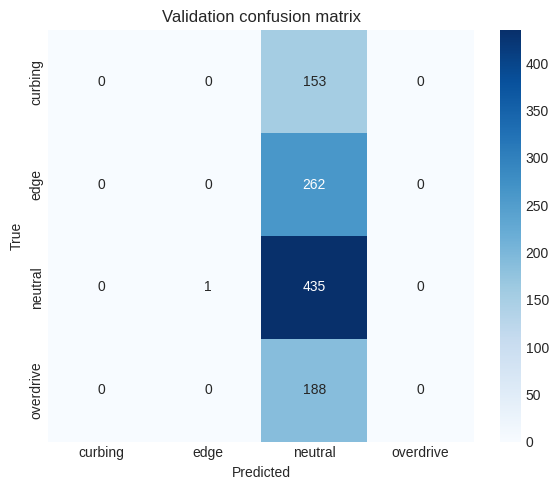

Saved to: outputs/wav2vec2_cvt


In [36]:
# Evaluate + save artifacts (train + validation)

def build_split_artifacts(pred_out, id2label):
    y_true = pred_out.label_ids
    y_pred = np.argmax(pred_out.predictions, axis=-1)

    ordered_ids = list(sorted(id2label.keys()))
    ordered_labels = [id2label[i] for i in ordered_ids]

    report = classification_report(
        y_true,
        y_pred,
        labels=ordered_ids,
        target_names=ordered_labels,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T

    cm = confusion_matrix(y_true, y_pred, labels=ordered_ids)
    cm_df = pd.DataFrame(cm, index=ordered_labels, columns=ordered_labels)

    metrics = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, labels=ordered_ids, average='macro', zero_division=0)),
        'precision_macro': float(precision_score(y_true, y_pred, labels=ordered_ids, average='macro', zero_division=0)),
        'recall_macro': float(recall_score(y_true, y_pred, labels=ordered_ids, average='macro', zero_division=0)),
    }

    return metrics, report_df, cm_df


def safe_trainer_evaluate(trainer, eval_dataset):
    try:
        return trainer.evaluate(eval_dataset=eval_dataset)
    except RuntimeError as e:
        msg = str(e)
        if 'on_train_begin must be called before on_evaluate' in msg:
            print('NotebookProgressCallback issue detected; skipping trainer.evaluate and using predict-based metrics.')
            return {'eval_skipped_due_to_callback_issue': True}
        raise


# Validation metrics from trainer (kept for backward compatibility)
val_trainer_metrics = safe_trainer_evaluate(trainer, val_ds)
print('Validation metrics (trainer):')
print(json.dumps(val_trainer_metrics, indent=2, ensure_ascii=False))

# Detailed classification metrics on train and val splits
train_pred = trainer.predict(train_ds)
val_pred = trainer.predict(val_ds)

train_metrics, train_report_df, train_cm_df = build_split_artifacts(train_pred, id2label)
val_metrics, val_report_df, val_cm_df = build_split_artifacts(val_pred, id2label)

print('\nTrain classification metrics:')
print(json.dumps(train_metrics, indent=2, ensure_ascii=False))
print('\nValidation classification metrics:')
print(json.dumps(val_metrics, indent=2, ensure_ascii=False))

print('\nTrain classification report:')
display(train_report_df)
print('\nValidation classification report:')
display(val_report_df)

# Plot validation confusion matrix (as before)
plt.figure(figsize=(8, 6))
sns.heatmap(val_cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Validation confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save per-split reports and confusion matrices
train_report_df.to_csv(OUTPUT_DIR / 'train_classification_report.csv')
train_cm_df.to_csv(OUTPUT_DIR / 'train_confusion_matrix.csv')

val_report_df.to_csv(OUTPUT_DIR / 'val_classification_report.csv')
val_cm_df.to_csv(OUTPUT_DIR / 'val_confusion_matrix.csv')

# Save aggregate metrics JSON
metrics_payload = {
    'train_metrics': train_metrics,
    'val_metrics': val_metrics,
    'val_trainer_metrics': val_trainer_metrics,
}
with open(OUTPUT_DIR / 'val_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

print('Saved to:', OUTPUT_DIR)


In [ ]:
# t-SNE visualization for current trained model
TSNE_PLOTS_DIR = Path('./tsne_plots')
TSNE_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

current_model = trainer.model
val_loader = trainer.get_eval_dataloader(val_ds)
run_name = OUTPUT_DIR.name

val_embeddings, val_labels, reference_vectors, class_names = extract_embeddings_and_references(
    model=current_model,
    dataloader=val_loader,
    processor=feature_extractor,
    device=DEVICE,
)

tsne_path = TSNE_PLOTS_DIR / f'tsne_{run_name}.png'
plot_tsne(
    embeddings=val_embeddings,
    labels=val_labels,
    references=reference_vectors,
    class_names=class_names,
    title=f't-SNE: {run_name}',
    save_path=tsne_path,
)

pca_path = TSNE_PLOTS_DIR / f'pca_{run_name}.png'
plot_pca(
    embeddings=val_embeddings,
    labels=val_labels,
    references=reference_vectors,
    class_names=class_names,
    title=f'PCA: {run_name}',
    save_path=pca_path,
)

print(f'Saved t-SNE plot to: {tsne_path}')
print(f'Saved PCA plot to: {pca_path}')


## Быстрые идеи для улучшения (опционально)
- Сделать второй прогон с `FREEZE_FEATURE_ENCODER=False` после 2-3 warmup эпох.
- Добавить `source_in_name`-aware split, чтобы device leakage был минимальным.
- Сравнить с `facebook/hubert-base-ls960` тем же пайплайном.
